In [1]:
# Problem 3: Customer Segmentation Using Hierarchical Clustering
# Scenario: A retail company wants to segment customers based on Annual Income and Spending Score.
# Task:
#     - Apply Agglomerative Hierarchical Clustering
#     - Use dendrogram to find optimal number of clusters
#     - Compare clusters with K-Means and evaluate using Davies–Bouldin Index.

# Problem 4: Compare Evaluation Metrics Across Algorithms
# Dataset: Any dataset like Iris or synthetic blobs.
# Task:
# Run all three clustering algorithms (K-Means, DBSCAN, Hierarchical) and compare their Silhouette Scores and Davies–Bouldin Indices.

# Problem 2: Apply DBSCAN on Noisy Data
# Dataset: Use make_moons(noise=0.1) from sklearn.datasets.
# Task:
# Apply DBSCAN to cluster this data and compare the performance with K-Means.

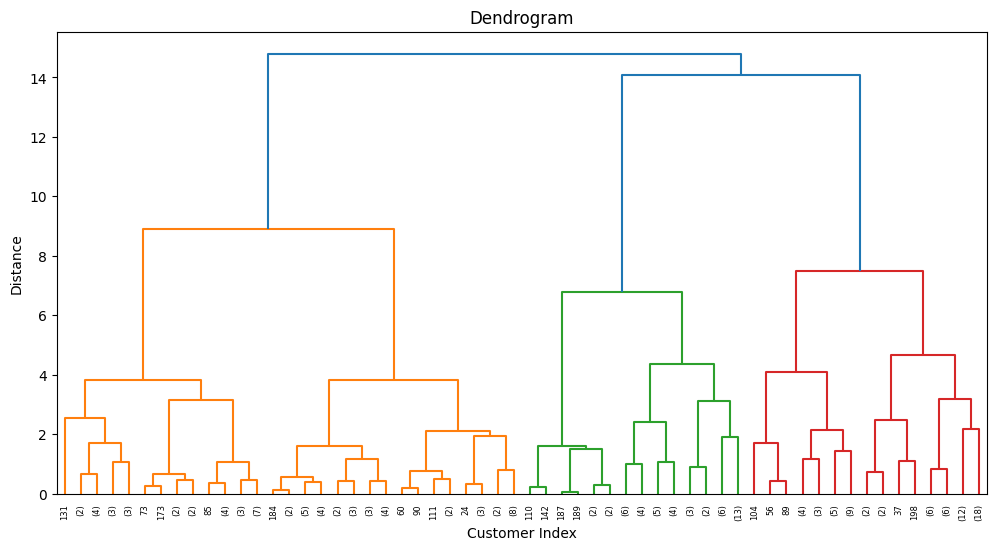

Davies-Bouldin Scores:
Agglomerative: 0.977
K-Means: 0.964


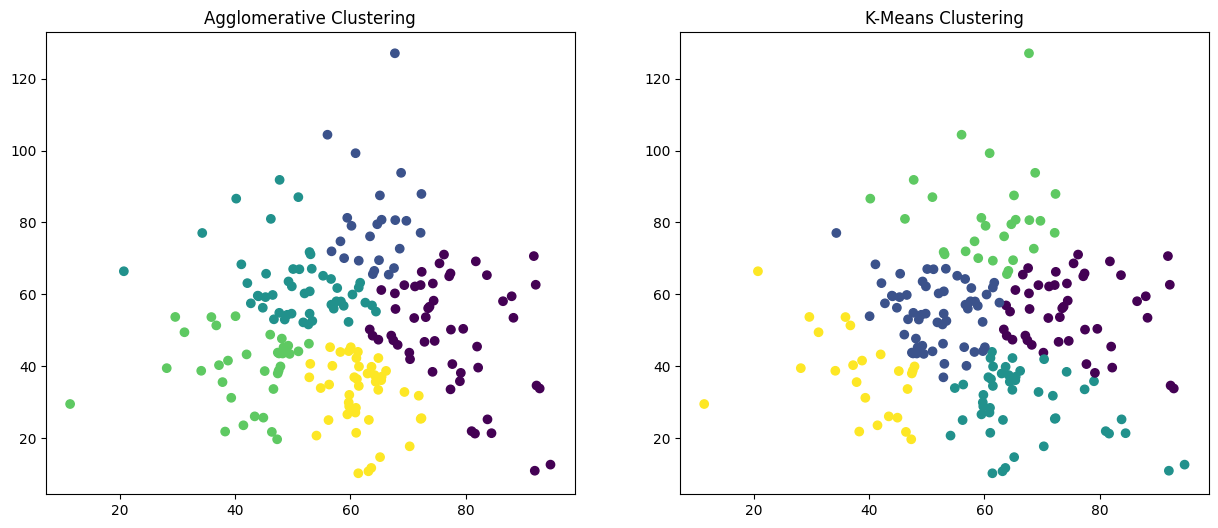

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import davies_bouldin_score

# Generate synthetic data
np.random.seed(42)
X = np.random.randn(200, 2) * np.array([15, 20]) + np.array([60, 50])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dendrogram
plt.figure(figsize=(12, 6))
linked = linkage(X_scaled, method='ward')
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Dendrogram')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()

# Hierarchical clustering (choose 5 clusters based on dendrogram)
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

# K-Means comparison
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation
print("Davies-Bouldin Scores:")
print(f"Agglomerative: {davies_bouldin_score(X_scaled, agg_labels):.3f}")
print(f"K-Means: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c=agg_labels, cmap='viridis')
plt.title('Agglomerative Clustering')

plt.subplot(1, 2, 2)
plt.scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis')
plt.title('K-Means Clustering')
plt.show()

In [7]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load Iris dataset
iris = load_iris()
X = iris.data

# Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define algorithms
algorithms = {
    'K-Means': KMeans(n_clusters=3, random_state=42),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=3)
}

# Evaluate each algorithm
results = []
for name, algo in algorithms.items():
    labels = algo.fit_predict(X_scaled)
    if len(set(labels)) > 1:  # Need at least 2 clusters for metrics
        sil_score = silhouette_score(X_scaled, labels)
        db_score = davies_bouldin_score(X_scaled, labels)
        results.append({
            'Algorithm': name,
            'Silhouette Score': sil_score,
            'Davies-Bouldin Index': db_score,
            'Clusters Found': len(set(labels))
        })

# Display results
results_df = pd.DataFrame(results)
print(results_df)

       Algorithm  Silhouette Score  Davies-Bouldin Index  Clusters Found
0        K-Means          0.479881              0.789363               3
1         DBSCAN          0.356516              7.124057               3
2  Agglomerative          0.446689              0.803467               3


DBSCAN Silhouette Score: 0.32413819915676867
K-Means Silhouette Score: 0.4805


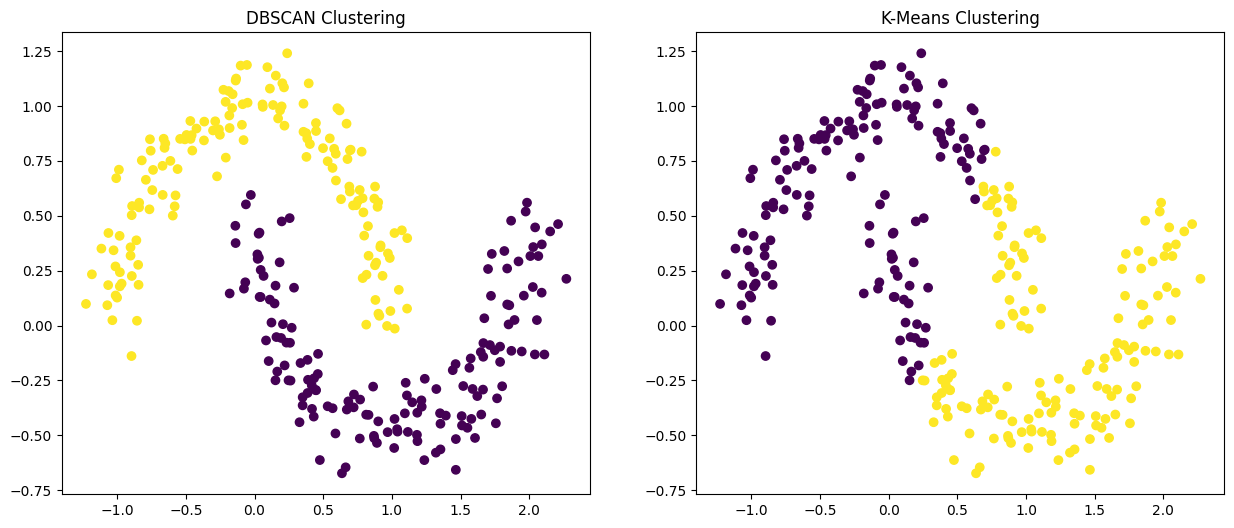

In [11]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Generate noisy moon data
X, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Apply K-Means for comparison
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Evaluate (when applicable)
dbscan_score = silhouette_score(X, dbscan_labels) if len(set(dbscan_labels)) > 1 else None
kmeans_score = silhouette_score(X, kmeans_labels)

print(f"DBSCAN Silhouette Score: {dbscan_score}")
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

# Visualization
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
plt.title('DBSCAN Clustering')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
plt.title('K-Means Clustering')
plt.show()

In [12]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer

df = pd.read_csv('your_dataset.csv')

# Assuming 'X' contains your features and 'y' contains your target variable
X = df.drop(columns=['Time', 'Pass/Fail'])
y = df['Pass/Fail']

# Remove constant features
selector = VarianceThreshold()
X_selected = selector.fit_transform(X)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_selected)

# Perform feature selection
selector_kbest = SelectKBest(score_func=f_classif, k=20)
X_train_selected = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_selected = selector_kbest.transform(X_test_scaled)

# Perform dimensionality reduction
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_selected)
X_test_pca = pca.transform(X_test_selected)

# Train a classifier (e.g., Random Forest) without dimensionality reduction
clf_before = RandomForestClassifier(n_estimators=100, random_state=42)
clf_before.fit(X_train_scaled, y_train)

# Make predictions and evaluate the model before dimensionality reduction
y_pred_before = clf_before.predict(X_test_scaled)
accuracy_before = accuracy_score(y_test, y_pred_before)
print(f'Accuracy before dimensionality reduction: {accuracy_before}')
# Train a classifier (e.g., Random Forest) on the reduced feature set
clf_after = RandomForestClassifier(n_estimators=100, random_state=42)
clf_after.fit(X_train_pca, y_train)

# Make predictions and evaluate the model after dimensionality reduction
y_pred_after = clf_after.predict(X_test_pca)
accuracy_after = accuracy_score(y_test, y_pred_after)
print(f'Accuracy after dimensionality reduction: {accuracy_after}')

FileNotFoundError: [Errno 2] No such file or directory: 'your_dataset.csv'